In [1]:
#NOTE: 
#model_v1 and model_v2 are not the final model, they are just retrained model to get the final model "model_v3".
#locate "training V3", as that is the final model used for this project, i had to train the model 3 times.
#Also locate below "final testing with model_v3" to see the testing output.  

In [1]:
# Install required libraries
!pip install --upgrade pip
!pip install ultralytics opencv-python numpy matplotlib

In [2]:
# Verify installation
from ultralytics import YOLO
import cv2#
import numpy as np
import matplotlib.pyplot as plt

print("Ultralytics YOLO installed successfully!")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib is available.")

Ultralytics YOLO installed successfully!
OpenCV version: 4.11.0
NumPy version: 1.26.4
Matplotlib is available.


# Segmentation and creating Yaml for image preprossesing 

In [ ]:
import cv2
import numpy as np
import os
import shutil
import random

# Define paths
image_dir = "/Users/deen/Desktop/head count/images/"  # Directory with full images and annotations
segmented_dir = "segmented_images"  # Directory to save segmented images and annotations
dataset_dir = "head_count_dataset1"  # Directory for the final dataset
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
train_images_dir = os.path.join(train_dir, "images")
train_labels_dir = os.path.join(train_dir, "labels")
val_images_dir = os.path.join(val_dir, "images")
val_labels_dir = os.path.join(val_dir, "labels")

# Create directories
os.makedirs(segmented_dir, exist_ok=True)
for directory in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
    os.makedirs(directory, exist_ok=True)

# List of image-annotation pairs
image_annotation_pairs = [
    ("/Users/deen/Desktop/head count/images/DSC09698.JPG", "/Users/deen/Desktop/head count/images/DSC09698.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09715.JPG", "/Users/deen/Desktop/head count/images/DSC09715.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09716.JPG", "/Users/deen/Desktop/head count/images/DSC09716.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09717.JPG", "/Users/deen/Desktop/head count/images/DSC09717.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09718.JPG", "/Users/deen/Desktop/head count/images/DSC09718.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09719.JPG", "/Users/deen/Desktop/head count/images/DSC09719.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09720.JPG", "/Users/deen/Desktop/head count/images/DSC09720.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09721.JPG", "/Users/deen/Desktop/head count/images/DSC09721.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09722.JPG", "/Users/deen/Desktop/head count/images/DSC09722.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09723.JPG", "/Users/deen/Desktop/head count/images/DSC09723.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09724.JPG", "/Users/deen/Desktop/head count/images/DSC09724.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09725.JPG", "/Users/deen/Desktop/head count/images/DSC09725.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09726.JPG", "/Users/deen/Desktop/head count/images/DSC09726.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09727.JPG", "/Users/deen/Desktop/head count/images/DSC09727.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09728.JPG", "/Users/deen/Desktop/head count/images/DSC09728.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09729.JPG", "/Users/deen/Desktop/head count/images/DSC09729.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09730.JPG", "/Users/deen/Desktop/head count/images/DSC09730.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09731.JPG", "/Users/deen/Desktop/head count/images/DSC09731.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09732.JPG", "/Users/deen/Desktop/head count/images/DSC09732.txt"),
    ("/Users/deen/Desktop/head count/images/DSC09733.JPG", "/Users/deen/Desktop/head count/images/DSC09733.txt"),
]

# Function to segment an image and its annotations
def segment_image(image_path, annotation_path, output_dir):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image at {image_path}")
        return
    
    height, width = img.shape[:2]
    image_name = os.path.splitext(os.path.basename(image_path))[0]

    # Load annotations
    annotations = []
    if os.path.exists(annotation_path):
        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    print(f"Invalid annotation format in {annotation_path}: {line}")
                    continue
                class_id, x_center, y_center, w, h = map(float, parts)
                x_center *= width
                y_center *= height
                w *= width
                h *= height
                annotations.append((class_id, x_center, y_center, w, h))
    else:
        print(f"Annotation file not found at {annotation_path}")
        return

    # Segment the image into 4 quadrants
    segments = [
        img[0:height//2, 0:width//2],          # Top-left
        img[0:height//2, width//2:width],      # Top-right
        img[height//2:height, 0:width//2],     # Bottom-left
        img[height//2:height, width//2:width]  # Bottom-right
    ]
    segment_names = ["top_left", "top_right", "bottom_left", "bottom_right"]
    segment_dims = [
        (0, 0, width//2, height//2),
        (width//2, 0, width, height//2),
        (0, height//2, width//2, height),
        (width//2, height//2, width, height)
    ]

    # Process each segment
    for i, (segment, name, (x_min, y_min, x_max, y_max)) in enumerate(zip(segments, segment_names, segment_dims)):
        segment_annotations = []
        
        # Filter annotations for this segment
        for class_id, x_center, y_center, w, h in annotations:
            x1 = x_center - w/2
            y1 = y_center - h/2
            x2 = x_center + w/2
            y2 = y_center + h/2
            
            # Check if the bounding box intersects this segment
            if (x1 < x_max and x2 > x_min and y1 < y_max and y2 > y_min):
                # Adjust coordinates relative to segment
                new_x_center = (max(x_min, x1) + min(x_max, x2)) / 2 - x_min
                new_y_center = (max(y_min, y1) + min(y_max, y2)) / 2 - y_min
                new_w = min(x_max, x2) - max(x_min, x1)
                new_h = min(y_max, y2) - max(y_min, y1)
                
                # Normalize to segment dimensions
                new_x_center /= (x_max - x_min)
                new_y_center /= (y_max - y_min)
                new_w /= (x_max - x_min)
                new_h /= (y_max - y_min)
                
                # Only include if the center is within the segment
                if 0 <= new_x_center <= 1 and 0 <= new_y_center <= 1:
                    segment_annotations.append((class_id, new_x_center, new_y_center, new_w, new_h))

        # Save segment image
        segment_path = os.path.join(output_dir, f"{image_name}_{name}.jpg")
        cv2.imwrite(segment_path, segment)
        print(f"Saved {segment_path} with {len(segment_annotations)} heads")

        # Save segment annotations
        if segment_annotations:
            annotation_path = os.path.join(output_dir, f"{image_name}_{name}.txt")
            with open(annotation_path, 'w') as f:
                for class_id, x_center, y_center, w, h in segment_annotations:
                    f.write(f"{int(class_id)} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
            print(f"Saved annotations to {annotation_path}")
        else:
            print(f"No heads in {segment_path}, skipping annotation file")

# Step 1: Segment all images
print("Starting segmentation of full images...")
for image_path, annotation_path in image_annotation_pairs:
    print(f"\nProcessing {image_path}")
    segment_image(image_path, annotation_path, segmented_dir)
print("\nSegmentation of all images complete!")

# Step 2: Organize the dataset
print("\nOrganizing dataset...")

# Get all segmented images and annotations
image_files = [f for f in os.listdir(segmented_dir) if f.endswith('.jpg')]
annotation_files = [f for f in os.listdir(segmented_dir) if f.endswith('.txt')]

# Ensure we have matching pairs
image_files.sort()
annotation_files.sort()
print(f"Found {len(image_files)} images and {len(annotation_files)} annotations.")

# Pair images with annotations
pairs = [(img, img.replace('.jpg', '.txt')) for img in image_files]

# Shuffle and split into train (80%) and val (20%)
random.shuffle(pairs)
train_split = int(0.8 * len(pairs))  # 80% for training
train_pairs = pairs[:train_split]    # ~64 images
val_pairs = pairs[train_split:]      # ~16 images

# Copy segmented files to train directory
for img_file, txt_file in train_pairs:
    shutil.copy(os.path.join(segmented_dir, img_file), os.path.join(train_images_dir, img_file))
    if os.path.exists(os.path.join(segmented_dir, txt_file)):
        shutil.copy(os.path.join(segmented_dir, txt_file), os.path.join(train_labels_dir, txt_file))
    else:
        print(f"Warning: Annotation {txt_file} not found for {img_file}")

# Copy segmented files to val directory
for img_file, txt_file in val_pairs:
    shutil.copy(os.path.join(segmented_dir, img_file), os.path.join(val_images_dir, img_file))
    if os.path.exists(os.path.join(segmented_dir, txt_file)):
        shutil.copy(os.path.join(segmented_dir, txt_file), os.path.join(val_labels_dir, txt_file))
    else:
        print(f"Warning: Annotation {txt_file} not found for {img_file}")

# Add full images to the training set
full_images_dir = "/Users/deen/Desktop/head count/images/"
full_image_files = [f for f in os.listdir(full_images_dir) if f.endswith('.jpg')]
for img_file in full_image_files:
    txt_file = img_file.replace('.jpg', '.txt')
    shutil.copy(os.path.join(full_images_dir, img_file), os.path.join(train_images_dir, img_file))
    if os.path.exists(os.path.join(full_images_dir, txt_file)):
        shutil.copy(os.path.join(full_images_dir, txt_file), os.path.join(train_labels_dir, txt_file))
    else:
        print(f"Warning: Annotation {txt_file} not found for {img_file}")

# Create data.yaml file
yaml_content = f"""\
train: {os.path.abspath(train_dir)}
val: {os.path.abspath(val_dir)}
nc: 1  # Number of classes
names: ['head']  # Class names
"""

yaml_path = os.path.join(dataset_dir, "data.yaml")
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# Print summary
print(f"\nDataset organized at: {os.path.abspath(dataset_dir)}")
print(f"Training set: {len(train_pairs) + len(full_image_files)} images (including {len(full_image_files)} full images)")
print(f"Validation set: {len(val_pairs)} images")
print(f"data.yaml created at: {yaml_path}")
print("\nDataset preparation complete!")

# Importing pretrained Yolov8 nano model

In [3]:
# Import YOLO
from ultralytics import YOLO

# Load the pre-trained YOLOv8 nano model
model = YOLO("yolov8n.pt")
print("Loaded pre-trained YOLOv8n model.")

# Train with the segmented dataset
model.train(
    data="head_count_dataset1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=4,
    lr0=0.001,
    patience=20,
    name="head_count_model_v1",
    augment=True,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.9,
    scale=0.7,
    box=0.1,
    cls=0.7,
    mixup=0.2,
    iou=0.6
)

print("Training complete! Model saved in 'runs/train/head_count_model_v1'.")

⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov8n.pt...


######################################################################## 100.0%


Loaded pre-trained YOLOv8n model.
New https://pypi.org/project/ultralytics/8.3.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=head_count_dataset1/data.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=head_count_model_v1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.6, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, 

train: Scanning /Users/deen/Desktop/Head count 2/head_count_dataset1/train/label

train: New cache created: /Users/deen/Desktop/Head count 2/head_count_dataset1/train/labels.cache


...


     92/100         0G    0.03314      2.107      1.263         48        640: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all         16        214      0.638      0.593      0.524      0.146
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 72, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

92 epochs completed in 0.818 hours.


Optimizer stripped from runs/detect/head_count_model_v1/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/head_count_model_v1/weights/best.pt, 6.2MB

Validating runs/detect/head_count_model_v1/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         16        214      0.672      0.579      0.596      0.176
Speed: 1.0ms preprocess, 156.1ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to runs/detect/head_count_model_v1
Training complete! Model saved in 'runs/train/head_count_model_v1'.


# Testing 

In [6]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

# Model path
model_path = "runs/detect/head_count_model_v1/weights/best.pt"

# Verify model exists
if not os.path.exists(model_path):
    print(f"Error: Model file not found at '{model_path}'.")
    raise FileNotFoundError(f"Model file not found at '{model_path}'.")

# Load the custom-trained YOLOv8 model
model = YOLO(model_path)
print(f"Loaded model from: {model_path}")

# Function to count heads
def count_heads(img, confidence_threshold=0.15, is_full_image=False):
    if img is None:
        print("Error: Image not loaded.")
        return 0, [], None
    
    # Lower confidence threshold for full images
    conf_thres = 0.1 if is_full_image else confidence_threshold
    
    results = model(img, imgsz=640, conf=conf_thres, iou=0.5)
    head_count = 0
    confidences = []
    all_scores = []

    for result in results:
        boxes = result.boxes
        print(f"Total boxes detected: {len(boxes)}")
        for box in boxes:
            conf = box.conf.item()
            cls = int(box.cls)
            all_scores.append(conf)
            print(f"Box: Class={cls}, Confidence={conf:.2f}")
            if cls == 0:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"Head: {conf:.2f}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                head_count += 1
                confidences.append(conf)

    print(f"All detection scores: {all_scores}")
    return head_count, confidences, img

# Process the image and plot results
def process_image(image_path, is_full_image=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return
    
    head_count, confidences, processed_img = count_heads(img, is_full_image=is_full_image)
    
    # Convert BGR to RGB for matplotlib display
    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)
    
    # Display the image with bounding boxes
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(processed_img_rgb)
    plt.title("Head Detection")
    plt.axis("off")
    
    # Plot the number of detected heads
    plt.subplot(1, 2, 2)
    plt.bar(["Image"], [head_count], color='skyblue')
    plt.xlabel("Image")
    plt.ylabel("Number of Detected Heads")
    plt.title("Heads Detected")
    
    plt.tight_layout()
    plt.show()
    
    # Plot confidence distribution
    if confidences:
        plt.figure(figsize=(5, 3))
        plt.hist(confidences, bins=10, color='lightgreen', edgecolor='black')
        plt.xlabel("Confidence Score")
        plt.ylabel("Frequency")
        plt.title("Confidence Distribution")
        plt.show()
    
    print(f"Detected heads: {head_count}")
    if confidences:
        print(f"Average confidence: {np.mean(confidences):.2f}")

# Test on all segmented images
segmented_images = [
    "segmented_images/DSC09724_top_left.jpg",
    "segmented_images/DSC09724_top_right.jpg",
    "segmented_images/DSC09724_bottom_left.jpg",
    "segmented_images/DSC09724_bottom_right.jpg"
]

for seg_path in segmented_images:
    if os.path.exists(seg_path):
        print(f"\nTesting on: {seg_path}")
        process_image(seg_path, is_full_image=False)

# Test on full image
image_path = "/Users/deen/Desktop/Head count 2/images/DSC09724.JPG"
print(f"\nTesting on full image: {image_path}")
process_image(image_path, is_full_image=True)

Loaded model from: runs/detect/head_count_model_v1/weights/best.pt

Testing on: segmented_images/DSC09724_top_left.jpg

0: 448x640 12 heads, 94.2ms
Speed: 6.2ms preprocess, 94.2ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 12
Box: Class=0, Confidence=0.56
Box: Class=0, Confidence=0.47
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.35
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.29
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.17
All detection scores: [0.5554208755493164, 0.4722088575363159, 0.464110404253006, 0.4523771107196808, 0.4193946123123169, 0.41338062286376953, 0.35760265588760376, 0.349564790725708, 0.30598050355911255, 0.28852930665016174, 0.2493915557861328, 0.1664436161518097]


<Figure size 1000x500 with 2 Axes>

<Figure size 500x300 with 1 Axes>

Detected heads: 12
Average confidence: 0.37

Testing on: segmented_images/DSC09724_top_right.jpg

0: 448x640 19 heads, 74.6ms
Speed: 2.2ms preprocess, 74.6ms inference, 4.5ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 19
Box: Class=0, Confidence=0.53
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.29
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.24
Box: Class=0, Confidence=0.23
Box: Class=0, Confidence=0.22
Box: Class=0, Confidence=0.22
Box: Class=0, Confidence=0.21
Box: Class=0, Confidence=0.20
Box: Class=0, Confidence=0.18
Box: Class=0, Confidence=0.17
All detection scores: [0.5289292931556702, 0.45794910192489624, 0.39881181716918945, 0.32774680852890015, 0.306174635887146, 0.2977616786956787, 0.2967226207256317, 0.289169996976852

<Figure size 1000x500 with 2 Axes>

...

<Figure size 500x300 with 1 Axes>

Detected heads: 15
Average confidence: 0.45

Testing on full image: /Users/deen/Desktop/Head count 2/images/DSC09724.JPG

0: 448x640 43 heads, 83.3ms
Speed: 4.3ms preprocess, 83.3ms inference, 4.5ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 43
Box: Class=0, Confidence=0.56
Box: Class=0, Confidence=0.54
Box: Class=0, Confidence=0.53
Box: Class=0, Confidence=0.50
Box: Class=0, Confidence=0.50
Box: Class=0, Confidence=0.48
Box: Class=0, Confidence=0.47
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.27
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.22
Box: Class=0, Confidence=0.22
Box: Class=0, Confidence=0.22
Box: Class=0, Confidence=0.21
Box: Cla

<Figure size 1000x500 with 2 Axes>

<Figure size 500x300 with 1 Axes>

Detected heads: 43
Average confidence: 0.27


# adding full images to the train set 

In [10]:
import os
import shutil

# Paths
full_images_dir = "/Users/deen/Desktop/Head count 2/images/"
train_images_dir = "head_count_dataset1/train/images"
train_labels_dir = "head_count_dataset1/train/labels"

# Verify the full images directory exists
print(f"Full images directory: {full_images_dir}")
if not os.path.exists(full_images_dir):
    raise FileNotFoundError(f"Full images directory not found at: {full_images_dir}")

# Create directories if they don't exist
os.makedirs(train_images_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)

# List of full images (handle .jpg and .JPG extensions)
full_image_files = [f for f in os.listdir(full_images_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
print(f"Found {len(full_image_files)} full images: {full_image_files}")

# Copy full images and annotations to train directory
for img_file in full_image_files:
    img_path = os.path.join(full_images_dir, img_file)
    # Match the annotation file based on the image filename (case-insensitive for extension)
    base_name = os.path.splitext(img_file)[0]
    possible_txt_extensions = [f"{base_name}.txt", f"{base_name}.TXT"]
    txt_file = None
    for ext in possible_txt_extensions:
        if os.path.exists(os.path.join(full_images_dir, ext)):
            txt_file = ext
            break
    
    txt_path = os.path.join(full_images_dir, txt_file) if txt_file else None
    
    # Copy image
    shutil.copy(img_path, os.path.join(train_images_dir, img_file))
    print(f"Copied image: {img_file}")
    
    # Copy annotation if it exists
    if txt_path and os.path.exists(txt_path):
        shutil.copy(txt_path, os.path.join(train_labels_dir, txt_file))
        print(f"Copied annotation: {txt_file}")
    else:
        print(f"Warning: Annotation not found for {img_file}")

# Verify the updated dataset
train_images = len([f for f in os.listdir(train_images_dir) if f.lower().endswith(('.jpg', '.jpeg'))])
val_images = len([f for f in os.listdir("head_count_dataset1/val/images") if f.lower().endswith(('.jpg', '.jpeg'))])
print(f"\nUpdated dataset:")
print(f"Training set: {train_images} images (including {len(full_image_files)} full images)")
print(f"Validation set: {val_images} images")

Full images directory: /Users/deen/Desktop/Head count 2/images/
Found 20 full images: ['DSC09721.JPG', 'DSC09720.JPG', 'DSC09722.JPG', 'DSC09723.JPG', 'DSC09727.JPG', 'DSC09733.JPG', 'DSC09732.JPG', 'DSC09726.JPG', 'DSC09730.JPG', 'DSC09724.JPG', 'DSC09718.JPG', 'DSC09719.JPG', 'DSC09725.JPG', 'DSC09731.JPG', 'DSC09728.JPG', 'DSC09715.JPG', 'DSC09729.JPG', 'DSC09717.JPG', 'DSC09716.JPG', 'DSC09698.JPG']
Copied image: DSC09721.JPG
Copied annotation: DSC09721.txt
Copied image: DSC09720.JPG
Copied annotation: DSC09720.txt
Copied image: DSC09722.JPG
Copied annotation: DSC09722.txt
Copied image: DSC09723.JPG
Copied annotation: DSC09723.txt
Copied image: DSC09727.JPG
Copied annotation: DSC09727.txt
Copied image: DSC09733.JPG
Copied annotation: DSC09733.txt
Copied image: DSC09732.JPG
Copied annotation: DSC09732.txt
Copied image: DSC09726.JPG
Copied annotation: DSC09726.txt
Copied image: DSC09730.JPG
Copied annotation: DSC09730.txt
Copied image: DSC09724.JPG
Copied annotation: DSC09724.txt
Cop

# re training (model_v2)

In [11]:
from ultralytics import YOLO

# Load the current model
model = YOLO("runs/detect/head_count_model_v1/weights/best.pt")
print("Loaded head_count_model_v1.")

# Train with the updated dataset (now includes full images)
model.train(
    data="head_count_dataset1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=4,
    lr0=0.001,
    patience=20,
    name="head_count_model_v2",
    augment=True,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.9,
    scale=0.7,
    box=0.1,
    cls=0.7,
    mixup=0.2,
    iou=0.6
)

print("Training complete! Model saved in 'runs/train/head_count_model_v2'.")

Loaded head_count_model_v1.
New https://pypi.org/project/ultralytics/8.3.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
engine/trainer: task=detect, mode=train, model=runs/detect/head_count_model_v1/weights/best.pt, data=head_count_dataset1/data.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=head_count_model_v2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.6, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agn

train: Scanning /Users/deen/Desktop/Head count 2/head_count_dataset1/train/label

train: New cache created: /Users/deen/Desktop/Head count 2/head_count_dataset1/train/labels.cache



val: Scanning /Users/deen/Desktop/Head count 2/head_count_dataset1/val/labels.ca

Plotting labels to runs/detect/head_count_model_v2/labels.jpg... 


...

     35/100         0G    0.03435      2.033       1.25        149        640: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all         16        214      0.657      0.555      0.545      0.163
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 15, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



35 epochs completed in 0.621 hours.
Optimizer stripped from runs/detect/head_count_model_v2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/head_count_model_v2/weights/best.pt, 6.2MB

Validating runs/detect/head_count_model_v2/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         16        214      0.622      0.579      0.556      0.172
Speed: 1.3ms preprocess, 181.4ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/detect/head_count_model_v2
Training complete! Model saved in 'runs/train/head_count_model_v2'.


# re testing with model_v2

In [12]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

# Update model path to head_count_model_v2
model_path = "runs/detect/head_count_model_v2/weights/best.pt"

# Verify model exists
if not os.path.exists(model_path):
    print(f"Error: Model file not found at '{model_path}'.")
    raise FileNotFoundError(f"Model file not found at '{model_path}'.")

# Load the custom-trained YOLOv8 model
model = YOLO(model_path)
print(f"Loaded model from: {model_path}")

# Function to count heads
def count_heads(img, confidence_threshold=0.15, is_full_image=False):
    if img is None:
        print("Error: Image not loaded.")
        return 0, [], None
    
    conf_thres = 0.1 if is_full_image else confidence_threshold
    
    results = model(img, imgsz=640, conf=conf_thres, iou=0.5)
    head_count = 0
    confidences = []
    all_scores = []

    for result in results:
        boxes = result.boxes
        print(f"Total boxes detected: {len(boxes)}")
        for box in boxes:
            conf = box.conf.item()
            cls = int(box.cls)
            all_scores.append(conf)
            print(f"Box: Class={cls}, Confidence={conf:.2f}")
            if cls == 0:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"Head: {conf:.2f}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                head_count += 1
                confidences.append(conf)

    print(f"All detection scores: {all_scores}")
    return head_count, confidences, img

# Process the image and plot results
def process_image(image_path, is_full_image=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return
    
    head_count, confidences, processed_img = count_heads(img, is_full_image=is_full_image)
    
    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(processed_img_rgb)
    plt.title("Head Detection")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.bar(["Image"], [head_count], color='skyblue')
    plt.xlabel("Image")
    plt.ylabel("Number of Detected Heads")
    plt.title("Heads Detected")
    
    plt.tight_layout()
    plt.show()
    
    if confidences:
        plt.figure(figsize=(5, 3))
        plt.hist(confidences, bins=10, color='lightgreen', edgecolor='black')
        plt.xlabel("Confidence Score")
        plt.ylabel("Frequency")
        plt.title("Confidence Distribution")
        plt.show()
    
    print(f"Detected heads: {head_count}")
    if confidences:
        print(f"Average confidence: {np.mean(confidences):.2f}")

# Test on all segmented images
segmented_images = [
    "segmented_images/DSC09724_top_left.jpg",
    "segmented_images/DSC09724_top_right.jpg",
    "segmented_images/DSC09724_bottom_left.jpg",
    "segmented_images/DSC09724_bottom_right.jpg"
]

for seg_path in segmented_images:
    if os.path.exists(seg_path):
        print(f"\nTesting on: {seg_path}")
        process_image(seg_path, is_full_image=False)

# Test on full image
image_path = "/Users/deen/Desktop/Head count 2/images/DSC09724.JPG"
print(f"\nTesting on full image: {image_path}")
process_image(image_path, is_full_image=True)

Loaded model from: runs/detect/head_count_model_v2/weights/best.pt

Testing on: segmented_images/DSC09724_top_left.jpg

0: 448x640 10 heads, 86.5ms
Speed: 4.0ms preprocess, 86.5ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 10
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.23
Box: Class=0, Confidence=0.19
Box: Class=0, Confidence=0.19
All detection scores: [0.4597752094268799, 0.4513216018676758, 0.40612199902534485, 0.3996239900588989, 0.38714393973350525, 0.3388531506061554, 0.29868119955062866, 0.22841697931289673, 0.192671000957489, 0.1866150200366974]


<Figure size 1000x500 with 2 Axes>

<Figure size 500x300 with 1 Axes>

Detected heads: 10
Average confidence: 0.33

Testing on: segmented_images/DSC09724_top_right.jpg

0: 448x640 17 heads, 81.8ms
Speed: 2.3ms preprocess, 81.8ms inference, 4.5ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 17
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.35
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.28
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.24
Box: Class=0, Confidence=0.23
Box: Class=0, Confidence=0.20
Box: Class=0, Confidence=0.19
Box: Class=0, Confidence=0.19
Box: Class=0, Confidence=0.18
Box: Class=0, Confidence=0.16
Box: Class=0, Confidence=0.16
All detection scores: [0.4484272301197052, 0.4052700102329254, 0.34776321053504944, 0.2988501191139221, 0.296436071395874, 0.28039854764938354, 0.2590242326259613, 0.2550133764743805, 0.2529493272304535, 0.23780906200408936, 0.233584284782409

<Figure size 1000x500 with 2 Axes>

...

<Figure size 500x300 with 1 Axes>

Detected heads: 14
Average confidence: 0.41

Testing on full image: /Users/deen/Desktop/Head count 2/images/DSC09724.JPG

0: 448x640 57 heads, 71.6ms
Speed: 4.8ms preprocess, 71.6ms inference, 3.9ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 57
Box: Class=0, Confidence=0.55
Box: Class=0, Confidence=0.54
Box: Class=0, Confidence=0.49
Box: Class=0, Confidence=0.48
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.43
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.38
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.32
Box: Class=0, Confidence=0.32
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.29
Box: Class=0, Confidence=0.27
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.23
Box: Class=0, Confidence=0.21
Box: Class=0, Confidence=0.21
Box: Cla

<Figure size 1000x500 with 2 Axes>

<Figure size 500x300 with 1 Axes>

Detected heads: 57
Average confidence: 0.24


# training v3 


In [15]:
from ultralytics import YOLO

# Load the current model
model = YOLO("runs/detect/head_count_model_v2/weights/best.pt")
print("Loaded head_count_model_v2.")

# Train with the updated dataset (now includes full images)
model.train(
    data="head_count_dataset1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=4,
    lr0=0.001,
    patience=20,
    name="head_count_model_v3",
    augment=True,
    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.9,
    scale=0.7,
    box=0.15,  # Increased to reduce false positives
    cls=0.8,   # Increased to reduce false positives
    mixup=0.2,
    iou=0.6
)

print("Training complete! Model saved in 'runs/train/head_count_model_v3'.")

Loaded head_count_model_v2.
New https://pypi.org/project/ultralytics/8.3.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
engine/trainer: task=detect, mode=train, model=runs/detect/head_count_model_v2/weights/best.pt, data=head_count_dataset1/data.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=head_count_model_v3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.6, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agn

train: Scanning /Users/deen/Desktop/Head count 2/head_count_dataset1/train/label
val: Scanning /Users/deen/Desktop/Head count 2/head_count_dataset1/val/labels.ca

Plotting labels to runs/detect/head_count_model_v3/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/head_count_model_v3
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100         0G     0.0508      2.248      1.276         73        640: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

...


     24/100         0G     0.0514      2.323       1.24         80        640: 1
                 Class     Images  Instances      Box(P          R      mAP50  m

                   all         16        214      0.574      0.519      0.491      0.132
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 4, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



24 epochs completed in 0.440 hours.
Optimizer stripped from runs/detect/head_count_model_v3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/head_count_model_v3/weights/best.pt, 6.2MB

Validating runs/detect/head_count_model_v3/weights/best.pt...
Ultralytics 8.3.104 🚀 Python-3.10.0 torch-2.2.2 CPU (Intel Core(TM) i5-1038NG7 2.00GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  m


                   all         16        214      0.609      0.611      0.584      0.168
Speed: 1.0ms preprocess, 146.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/head_count_model_v3
Training complete! Model saved in 'runs/train/head_count_model_v3'.


# final Testing with model_V3 

Loaded model from: runs/detect/head_count_model_v3/weights/best.pt

Testing on: segmented_images/DSC09724_top_left.jpg

0: 448x640 12 heads, 104.6ms
Speed: 7.4ms preprocess, 104.6ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 12
Box: Class=0, Confidence=0.49
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.38
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.21
Box: Class=0, Confidence=0.20
Box: Class=0, Confidence=0.19
All detection scores: [0.4941742420196533, 0.44745752215385437, 0.40806370973587036, 0.38876962661743164, 0.3754883110523224, 0.36564502120018005, 0.3602169454097748, 0.34265345335006714, 0.34052398800849915, 0.20717640221118927, 0.19641467928886414, 0.1924455165863037]


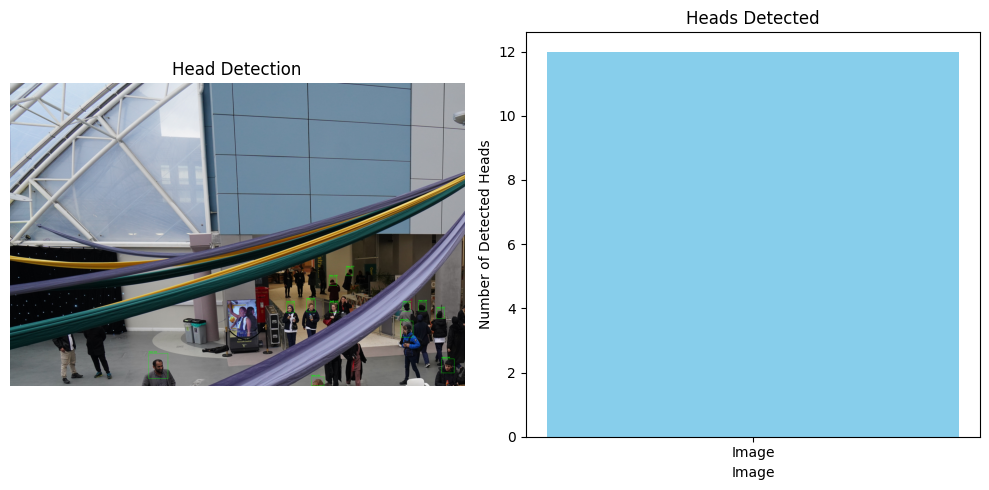

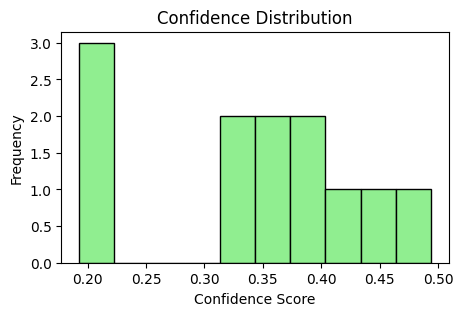

Detected heads: 12
Average confidence: 0.34

Testing on: segmented_images/DSC09724_top_right.jpg

0: 448x640 16 heads, 153.8ms
Speed: 8.6ms preprocess, 153.8ms inference, 8.8ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 16
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.35
Box: Class=0, Confidence=0.33
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.30
Box: Class=0, Confidence=0.28
Box: Class=0, Confidence=0.27
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.25
Box: Class=0, Confidence=0.23
Box: Class=0, Confidence=0.21
Box: Class=0, Confidence=0.20
All detection scores: [0.4019891321659088, 0.38995054364204407, 0.3735925257205963, 0.3710213899612427, 0.34724289178848267, 0.33045893907546997, 0.30914080142974854, 0.2992187440395355, 0.29555389285087585, 0.2841750979423523, 0.2671296000480652, 0.26463547348976135, 0

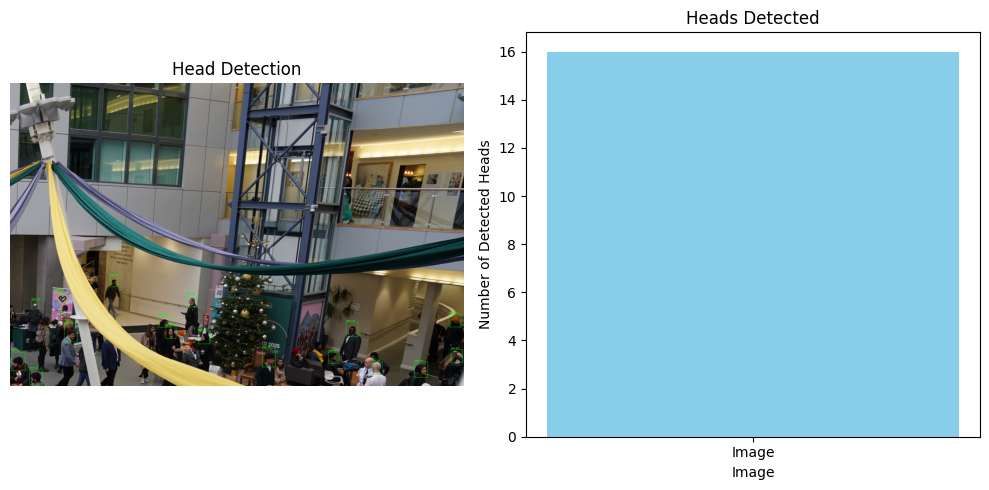

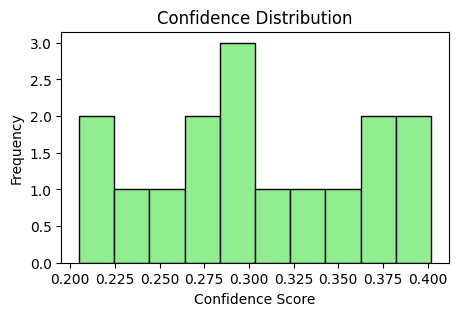

Detected heads: 16
Average confidence: 0.30

Testing on: segmented_images/DSC09724_bottom_left.jpg

0: 448x640 14 heads, 93.2ms
Speed: 4.5ms preprocess, 93.2ms inference, 5.6ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 14
Box: Class=0, Confidence=0.57
Box: Class=0, Confidence=0.48
Box: Class=0, Confidence=0.47
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.45
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.28
Box: Class=0, Confidence=0.27
All detection scores: [0.5724198222160339, 0.4808772802352905, 0.47183579206466675, 0.4505434036254883, 0.446114718914032, 0.42347922921180725, 0.4083685874938965, 0.4061506688594818, 0.4010509252548218, 0.36064448952674866, 0.3585579991340637, 0.3360878527164459, 0.27909091114997864, 0.2717331349849701]


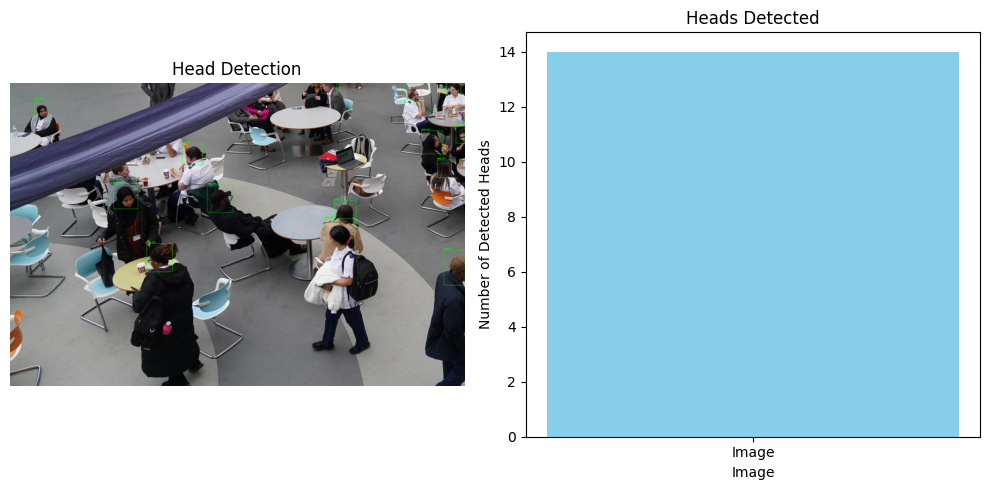

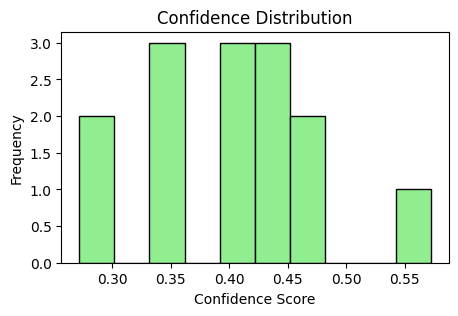

Detected heads: 14
Average confidence: 0.40

Testing on: segmented_images/DSC09724_bottom_right.jpg

0: 448x640 12 heads, 108.0ms
Speed: 10.2ms preprocess, 108.0ms inference, 5.9ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 12
Box: Class=0, Confidence=0.51
Box: Class=0, Confidence=0.44
Box: Class=0, Confidence=0.44
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.38
Box: Class=0, Confidence=0.38
Box: Class=0, Confidence=0.35
Box: Class=0, Confidence=0.34
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.27
All detection scores: [0.5094112157821655, 0.439292848110199, 0.4359895586967468, 0.4229864180088043, 0.41866594552993774, 0.4026751220226288, 0.38101881742477417, 0.37948518991470337, 0.3483866751194, 0.3412371277809143, 0.31420421600341797, 0.2680167853832245]


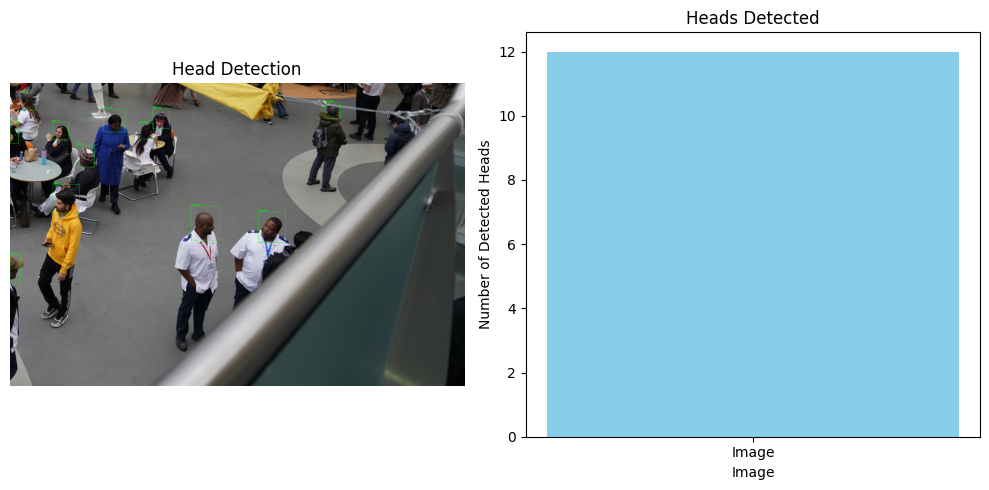

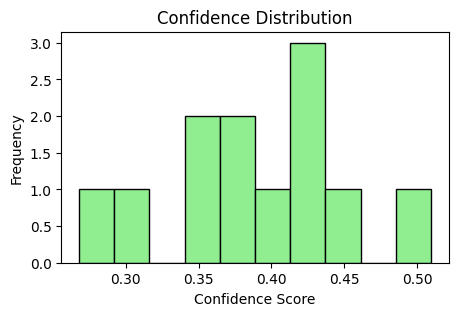

Detected heads: 12
Average confidence: 0.39

Testing on full image: /Users/deen/Desktop/Head count 2/images/DSC09724.JPG

0: 448x640 45 heads, 96.6ms
Speed: 8.0ms preprocess, 96.6ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)
Total boxes detected: 45
Box: Class=0, Confidence=0.56
Box: Class=0, Confidence=0.53
Box: Class=0, Confidence=0.50
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.46
Box: Class=0, Confidence=0.44
Box: Class=0, Confidence=0.42
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.41
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.40
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.39
Box: Class=0, Confidence=0.37
Box: Class=0, Confidence=0.36
Box: Class=0, Confidence=0.31
Box: Class=0, Confidence=0.28
Box: Class=0, Confidence=0.28
Box: Class=0, Confidence=0.27
Box: Class=0, Confidence=0.27
Box: Class=0, Confidence=0.26
Box: Class=0, Confidence=0.25
Box: Cla

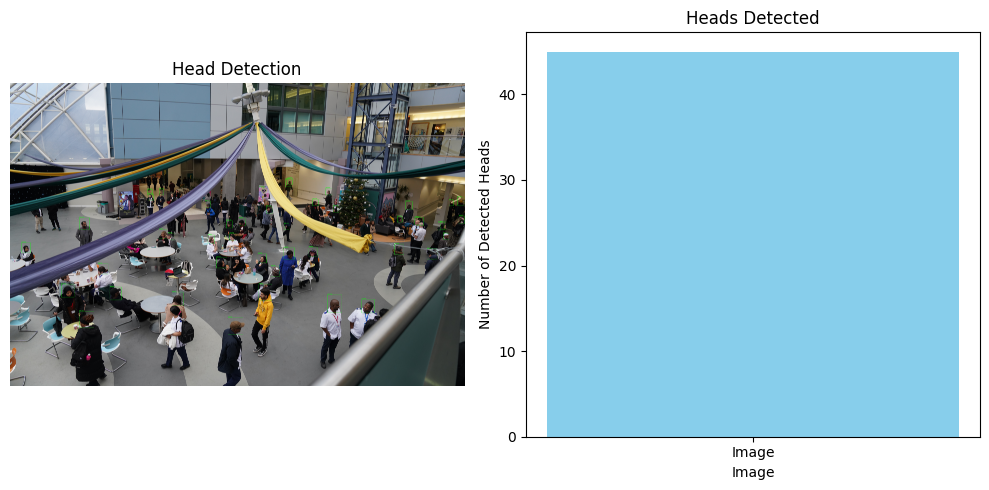

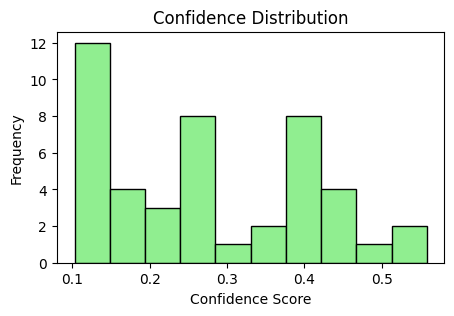

Detected heads: 45
Average confidence: 0.28


In [2]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

# Model path for head_count_model_v3
model_path = "runs/detect/head_count_model_v3/weights/best.pt"

# Verify model exists
if not os.path.exists(model_path):
    print(f"Error: Model file not found at '{model_path}'.")
    raise FileNotFoundError(f"Model file not found at '{model_path}'.")

# Load the custom-trained YOLOv8 model
model = YOLO(model_path)
print(f"Loaded model from: {model_path}")

# Function to count heads
def count_heads(img, confidence_threshold=0.19, is_full_image=False):
    if img is None:
        print("Error: Image not loaded.")
        return 0, [], None
    
    conf_thres = 0.1 if is_full_image else confidence_threshold
    
    results = model(img, imgsz=640, conf=conf_thres, iou=0.5)
    head_count = 0
    confidences = []
    all_scores = []

    for result in results:
        boxes = result.boxes
        print(f"Total boxes detected: {len(boxes)}")
        for box in boxes:
            conf = box.conf.item()
            cls = int(box.cls)
            all_scores.append(conf)
            print(f"Box: Class={cls}, Confidence={conf:.2f}")
            if cls == 0:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"Head: {conf:.2f}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                head_count += 1
                confidences.append(conf)

    print(f"All detection scores: {all_scores}")
    return head_count, confidences, img

# Process the image and plot results
def process_image(image_path, is_full_image=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return
    
    head_count, confidences, processed_img = count_heads(img, is_full_image=is_full_image)
    
    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(processed_img_rgb)
    plt.title("Head Detection")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.bar(["Image"], [head_count], color='skyblue')
    plt.xlabel("Image")
    plt.ylabel("Number of Detected Heads")
    plt.title("Heads Detected")
    
    plt.tight_layout()
    plt.show()
    
    if confidences:
        plt.figure(figsize=(5, 3))
        plt.hist(confidences, bins=10, color='lightgreen', edgecolor='black')
        plt.xlabel("Confidence Score")
        plt.ylabel("Frequency")
        plt.title("Confidence Distribution")
        plt.show()
    
    print(f"Detected heads: {head_count}")
    if confidences:
        print(f"Average confidence: {np.mean(confidences):.2f}")

# Test on all segmented images
segmented_images = [
    "segmented_images/DSC09724_top_left.jpg", #replace with any segmented image
    "segmented_images/DSC09724_top_right.jpg",
    "segmented_images/DSC09724_bottom_left.jpg",
    "segmented_images/DSC09724_bottom_right.jpg"
]

for seg_path in segmented_images:
    if os.path.exists(seg_path):
        print(f"\nTesting on: {seg_path}")
        process_image(seg_path, is_full_image=False)

# Test on full image
image_path = "/Users/deen/Desktop/Head count 2/images/DSC09724.JPG" #replace with your image path
print(f"\nTesting on full image: {image_path}")
process_image(image_path, is_full_image=True)